# Análisis y corrección del PKL v3
Herramienta interactiva para:
- Visualizar los prototipos del PKL
- Analizar clasificaciones frame a frame
- Ver errores: unknowns, low-margin, desacuerdos P1↔Final
- Ajustar umbrales en vivo
- Parchear el PKL (mover detecciones entre clases, añadir porteros)

In [157]:
import sys, pickle, cv2, copy, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import hsv_to_rgb
from collections import Counter, defaultdict
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')
from pipeline_core import (
    preprocess_half, init_undistort_maps,
    get_grass_hue, get_torso_crop, get_player_color,
    get_hue_signature_no_mask, get_hue_signature_masked,
    hue_sig_distance, extract_sam_masks_batch,
    classify_player_v3, classify_player,
    _HUE_BINS,
    CLASSIFY_V3_MAX_SCORE, CLASSIFY_V3_MARGIN, CLASSIFY_V3_CONFIDENT_MARGIN,
)
from ultralytics import YOLO
%matplotlib inline
print('Imports OK')

Imports OK


In [158]:
# ── CONFIG — edita aquí ───────────────────────────────────────────────────────
PKL_PATH   = 'prototypes_v3_nuevo.pkl'   # PKL a analizar
VIDEO_PATH = 'data/videos/veo_panoramico_banyoles.mp4'
MODEL_PATH = 'runs/detect/modelo_players_v23/weights/best.pt'
SAM_PATH   = 'sam2_t.pt'                # SAM2 — usa '' para deshabilitar
SAMPLE_SEC = 90      # segundos a muestrear (ignorado si INTERVALS != None)
STEP_S     = 2.5     # step entre frames
CONF       = 0.40    # confianza mínima YOLO

# Intervalos a muestrear del partido. None = primeros SAMPLE_SEC segundos.
# String formato generar_prototipos: '2:00-45:30,47:30-90:00'
# O lista de tuplas de segundos:     [(120, 2730), (2850, 5400)]
INTERVALS  = "5:00-10:00"

# Umbrales iniciales (copiados de pipeline_core)
MAX_SCORE   = CLASSIFY_V3_MAX_SCORE        # 0.38
MIN_MARGIN  = CLASSIFY_V3_MARGIN           # 0.04
CONF_MARGIN = CLASSIFY_V3_CONFIDENT_MARGIN # 0.10

# Colores por clase (RGB 0-1)
CLASS_COLOR = {
    'player_home': (0.20, 0.45, 1.00),
    'player_away': (1.00, 0.20, 0.20),
    'gk_home':     (0.00, 0.90, 0.90),
    'gk_away':     (1.00, 0.60, 0.00),
    'referee':     (0.90, 0.90, 0.10),
    'unknown':     (0.55, 0.55, 0.55),
}

def _bgr(cls):
    r, g, b = CLASS_COLOR.get(cls, (0.5, 0.5, 0.5))
    return (int(255*b), int(255*g), int(255*r))

print('Config OK')
print(f'MAX_SCORE={MAX_SCORE}  MIN_MARGIN={MIN_MARGIN}  CONF_MARGIN={CONF_MARGIN}')
print(f'SAM_PATH={SAM_PATH!r}')
if INTERVALS:
    print(f'INTERVALS={INTERVALS}')
else:
    print(f'SAMPLE_SEC={SAMPLE_SEC}s  STEP_S={STEP_S}s')

Config OK
MAX_SCORE=0.38  MIN_MARGIN=0.04  CONF_MARGIN=0.1
SAM_PATH='sam2_t.pt'
INTERVALS=5:00-10:00


## 1. Prototipos del PKL

PKL: prototypes_v3_nuevo.pkl  (5 clases)

  gk_away        :  346 muestras  hue_sig[:4]=['0.009', '0.715', '0.168', '0.013']
  gk_home        :  314 muestras  hue_sig[:4]=['0.003', '0.005', '0.074', '0.228']
  player_away    :  907 muestras  hue_sig[:4]=['0.090', '0.391', '0.167', '0.020']
  player_home    : 9064 muestras  hue_sig[:4]=['0.003', '0.025', '0.015', '0.005']
  referee        : 1011 muestras  hue_sig[:4]=['0.015', '0.147', '0.075', '0.008']


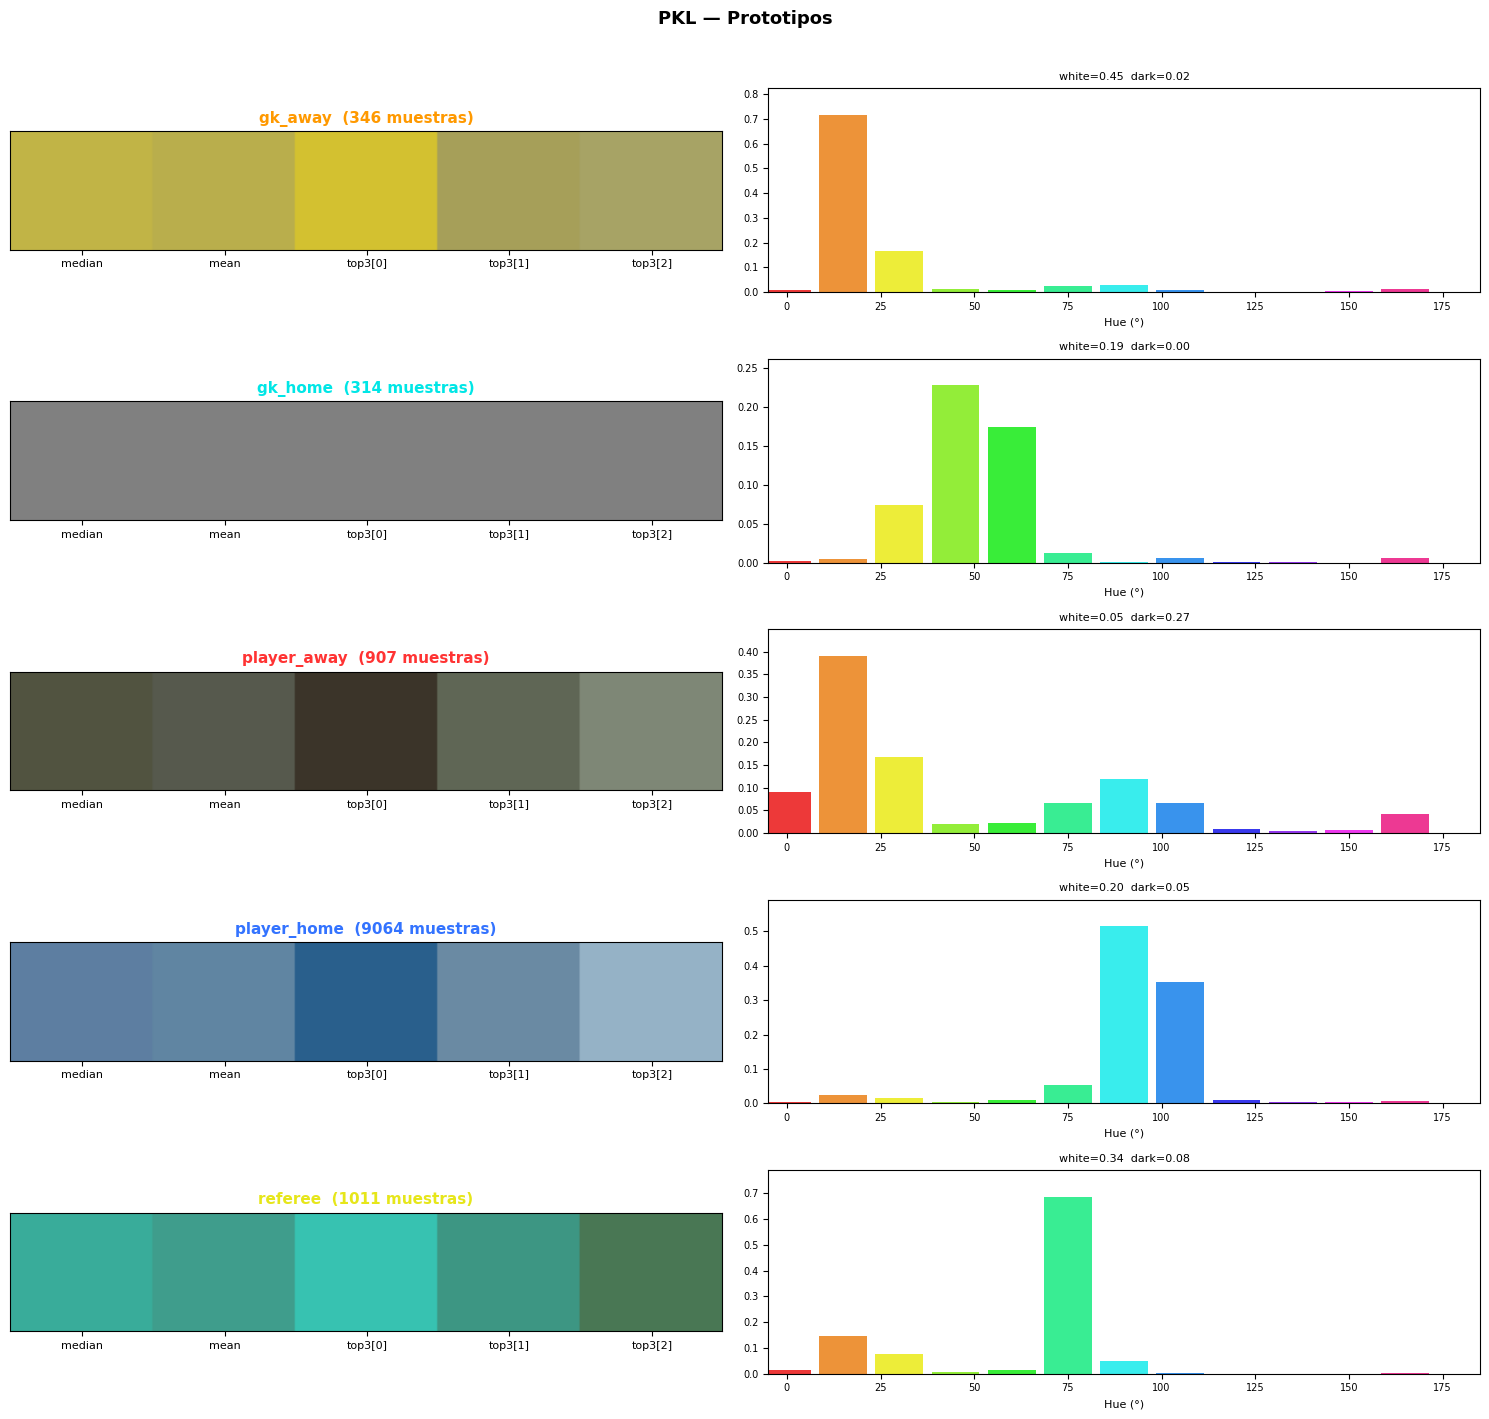

In [159]:
with open(PKL_PATH, 'rb') as f:
    proto_dict = pickle.load(f)

print(f'PKL: {PKL_PATH}  ({len(proto_dict)} clases)')
print()
for cls, p in sorted(proto_dict.items()):
    sig4 = [f'{v:.3f}' for v in p.get('hue_sig', [])[:4]]
    print(f'  {cls:15s}: {p.get("n_samples","?"):>4} muestras  hue_sig[:4]={sig4}')

# ── Visualización ────────────────────────────────────────────────────────────
n_cls = len(proto_dict)
fig, axes = plt.subplots(n_cls, 2, figsize=(15, 2.8 * n_cls), squeeze=False)

x_hue = np.arange(_HUE_BINS) * 180 / _HUE_BINS
hue_colors = [hsv_to_rgb([v / 180, 0.85, 0.92]) for v in x_hue]

for row_i, (cls, proto) in enumerate(sorted(proto_dict.items())):
    ax_c, ax_h = axes[row_i]
    col = CLASS_COLOR.get(cls, (0.6, 0.6, 0.6))

    # — Swatches BGR ——————————————————————————————————————
    keys = [('median', proto.get('median', [128,128,128])),
            ('mean',   proto.get('mean',   [128,128,128]))]
    for i, t in enumerate(proto.get('top3', [])):
        keys.append((f'top3[{i}]', t))

    sw_w = len(keys) * 60
    swatch = np.zeros((50, sw_w, 3), dtype=np.uint8)
    xticks, xlabels = [], []
    for i, (name, bgr) in enumerate(keys):
        swatch[:, i*60:(i+1)*60] = [bgr[2], bgr[1], bgr[0]]  # BGR->RGB
        xticks.append(i*60+30); xlabels.append(name)

    ax_c.imshow(swatch)
    ax_c.set_xticks(xticks); ax_c.set_xticklabels(xlabels, fontsize=8); ax_c.set_yticks([])
    ax_c.set_title(f'{cls}  ({proto.get("n_samples","?")} muestras)',
                   color=col, fontsize=11, fontweight='bold')

    # — Hue signature ——————————————————————————————————————
    sig  = np.array(proto.get('hue_sig', [0]*(_HUE_BINS+2)), dtype=np.float32)
    bins = sig[:_HUE_BINS]
    wf   = sig[_HUE_BINS]   if len(sig) > _HUE_BINS   else 0
    df   = sig[_HUE_BINS+1] if len(sig) > _HUE_BINS+1 else 0

    ax_h.bar(x_hue, bins, width=180/_HUE_BINS*0.85, color=hue_colors, alpha=0.9)
    ax_h.set_xlim(-5, 185)
    ax_h.set_ylim(0, max(0.01, bins.max() * 1.15))
    ax_h.set_xlabel('Hue (°)', fontsize=8); ax_h.tick_params(labelsize=7)
    ax_h.set_title(f'white={wf:.2f}  dark={df:.2f}', fontsize=8)

plt.suptitle('PKL — Prototipos', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2. Muestrear vídeo y clasificar

In [160]:
print('Cargando YOLO...')
model_yolo = YOLO(MODEL_PATH)
init_undistort_maps()

# ── Cargar SAM2 ───────────────────────────────────────────────────────────────
model_sam = None
_sam_path = (SAM_PATH or '').strip()
if _sam_path:
    print(f'Cargando SAM2 ({_sam_path})...')
    try:
        from ultralytics import SAM
        model_sam = SAM(_sam_path)
        print('  SAM2 listo — se usarán siluetas para hue_sig')
    except Exception as e:
        print(f'  SAM2 no disponible ({e}) — fallback a torso crop')
else:
    print('  SAM2 deshabilitado')

# ── Generar timestamps ────────────────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
fps_v     = cap.get(cv2.CAP_PROP_FPS) or 30.0
total_sec = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) / fps_v
cap.release()

def _parse_time(s):
    s = s.strip(); p = s.split(':')
    if len(p) == 3: return int(p[0])*3600 + int(p[1])*60 + float(p[2])
    if len(p) == 2: return int(p[0])*60 + float(p[1])
    return float(p[0])

def _parse_intervals(raw):
    if not raw: return None
    if isinstance(raw, (list, tuple)): return list(raw)
    ivs = []
    for part in raw.split(','):
        part = part.strip(); idx = part.rfind('-')
        ivs.append((_parse_time(part[:idx]), _parse_time(part[idx+1:])))
    return ivs

_ivs = _parse_intervals(INTERVALS)
if _ivs:
    ts_all = []
    for s, e in _ivs:
        ts_all.extend(np.arange(s, min(e, total_sec - 1), STEP_S).tolist())
    timestamps = np.array(sorted(ts_all))
    iv_str     = '  |  '.join(f'{s/60:.1f}m-{e/60:.1f}m' for s, e in _ivs)
    total_iv   = sum(e - s for s, e in _ivs)
    print(f'Intervalos: {iv_str}  ({total_iv:.0f}s útiles)')
else:
    timestamps = np.arange(0, min(SAMPLE_SEC, total_sec - 1), STEP_S)

print(f'Video: {total_sec:.0f}s @ {fps_v:.1f}fps  →  {len(timestamps)} frames x 2 cámaras')

# ── Sampling + clasificación ──────────────────────────────────────────────────
detections = []
cap = cv2.VideoCapture(VIDEO_PATH)

for fi, t in enumerate(timestamps):
    if fi % 5 == 0:
        print(f'\r  [{fi:3d}/{len(timestamps)}] {100*fi/len(timestamps):.0f}%  '
              f't={t:.0f}s  dets={len(detections)}', end='')

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(t * fps_v))
    ret, frame_raw = cap.read()
    if not ret:
        continue

    h_fr = frame_raw.shape[0]
    for half_raw, cam_side in [
        (frame_raw[:h_fr//2], 'left'),
        (frame_raw[h_fr//2:], 'right'),
    ]:
        cam_img = preprocess_half(half_raw, cam_side)
        gh = get_grass_hue(cam_img) or 55.0
        results = model_yolo(cam_img, verbose=False, conf=CONF)
        if not results or results[0].boxes is None:
            continue

        boxes_np = results[0].boxes.xyxy.cpu().numpy()
        confs_np = results[0].boxes.conf.cpu().numpy()

        # SAM2 batch para toda la cámara de este frame
        bboxes_list = [(int(b[0]), int(b[1]), int(b[2]), int(b[3])) for b in boxes_np]
        sam_masks   = extract_sam_masks_batch(cam_img, bboxes_list, model_sam)

        for idx_b, (box_t, c_t) in enumerate(zip(boxes_np, confs_np)):
            x1, y1, x2, y2 = map(int, box_t)
            crop = cam_img[y1:y2, x1:x2]
            if crop.size == 0 or (y2 - y1) < 28:
                continue

            mask = sam_masks[idx_b] if idx_b < len(sam_masks) else None

            # Hue sig con SAM2 si disponible, si no torso crop
            hue_sig = get_hue_signature_masked(crop, mask, gh).tolist()

            scores_v3 = {
                cls: hue_sig_distance(hue_sig, proto['hue_sig'])
                for cls, proto in proto_dict.items()
                if 'hue_sig' in proto
            }

            if scores_v3:
                sorted_s    = sorted(scores_v3.items(), key=lambda x: x[1])
                best_cls_p1 = sorted_s[0][0]
                best_scr_p1 = sorted_s[0][1]
                second_scr  = sorted_s[1][1] if len(sorted_s) > 1 else best_scr_p1
                margin_p1   = second_scr - best_scr_p1
                p1_unc      = best_scr_p1 > MAX_SCORE or margin_p1 < MIN_MARGIN
                cls_p1      = 'unknown' if p1_unc else best_cls_p1
            else:
                best_cls_p1 = 'unknown'; best_scr_p1 = 1.0
                margin_p1 = 0.0; p1_unc = True; cls_p1 = 'unknown'

            cls_p2, score_p2 = classify_player(crop, proto_dict, gh)

            if p1_unc or margin_p1 < CONF_MARGIN:
                cls_final = cls_p2 if cls_p2 != 'unknown' else cls_p1
            else:
                cls_final = cls_p1

            detections.append({
                'crop':      cv2.resize(crop, (52, 88)),
                'hue_sig':   hue_sig,
                'scores_v3': scores_v3,
                'cls_p1':    cls_p1,
                'score_p1':  best_scr_p1,
                'margin_p1': margin_p1,
                'cls_p2':    cls_p2,
                'score_p2':  score_p2,
                'cls_final': cls_final,
                'disagree':  cls_p1 != cls_final,
                't':         float(t),
                'cam':       cam_side,
                'bbox':      (x1, y1, x2, y2),
                'yolo_conf': float(c_t),
                'gh':        float(gh),
                'used_sam':  mask is not None,
            })

cap.release()
n_sam = sum(1 for d in detections if d['used_sam'])
print(f'\n\nTotal: {len(detections)} detecciones  (SAM2: {n_sam} / {len(detections)})')

counts_fin = Counter(d['cls_final'] for d in detections)
for c, n in sorted(counts_fin.items(), key=lambda x: -x[1]):
    print(f'  {c:15s}: {n:4d}  ({100*n/len(detections):.1f}%)')

Cargando YOLO...
Cargando SAM2 (sam2_t.pt)...
  SAM2 listo — se usarán siluetas para hue_sig
Intervalos: 5.0m-10.0m  (300s útiles)
Video: 7198s @ 30.0fps  →  120 frames x 2 cámaras
  [ 40/120] 33%  t=400s  dets=959

KeyboardInterrupt: 

## 3. Resumen estadístico

Clase                   Pass1   Final      Δ
─────────────────────────────────────────────
  player_home           1095    1541   +446
  player_away            710     565   -145
  unknown                562     296   -266
  referee                135     124    -11
  gk_away                 78      54    -24
  gk_home                 10      10      0
─────────────────────────────────────────────

  Option B actuó (desacuerdos): 446 (17.2%)
  Unknown rescatados por B:     266
  Low-margin < 0.10:            339


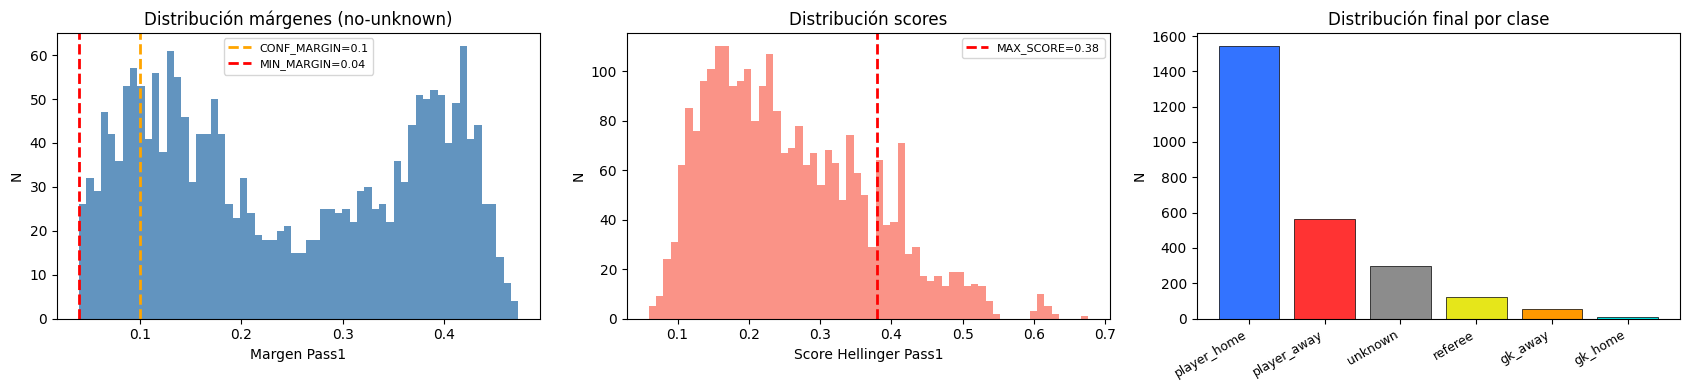

In [ ]:
counts_p1  = Counter(d['cls_p1']    for d in detections)
counts_fin = Counter(d['cls_final'] for d in detections)
n_total    = len(detections)
n_disagree = sum(1 for d in detections if d['disagree'])
n_rescued  = sum(1 for d in detections if d['cls_p1'] == 'unknown' and d['cls_final'] != 'unknown')
n_low_m    = sum(1 for d in detections
                 if 0 < d['margin_p1'] < CONF_MARGIN and d['cls_p1'] != 'unknown')

print(f'{"Clase":22s} {"Pass1":>6}  {"Final":>6}  {"Δ":>5}')
print('─' * 45)
all_cls = sorted(set(counts_p1) | set(counts_fin), key=lambda c: -counts_fin.get(c, 0))
for c in all_cls:
    p1n = counts_p1.get(c, 0); fn = counts_fin.get(c, 0)
    d   = fn - p1n
    sym = f'+{d}' if d > 0 else (str(d) if d < 0 else ' 0')
    print(f'  {c:20s} {p1n:5d}   {fn:5d}  {sym:>5}')
print('─' * 45)
print(f'\n  Option B actuó (desacuerdos): {n_disagree} ({100*n_disagree/max(1,n_total):.1f}%)')
print(f'  Unknown rescatados por B:     {n_rescued}')
print(f'  Low-margin < {CONF_MARGIN:.2f}:            {n_low_m}')

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Histograma márgenes
margins = [d['margin_p1'] for d in detections if d['cls_p1'] != 'unknown']
axes[0].hist(margins, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(CONF_MARGIN, color='orange', lw=2, ls='--', label=f'CONF_MARGIN={CONF_MARGIN}')
axes[0].axvline(MIN_MARGIN,  color='red',    lw=2, ls='--', label=f'MIN_MARGIN={MIN_MARGIN}')
axes[0].set_xlabel('Margen Pass1'); axes[0].set_ylabel('N')
axes[0].set_title('Distribución márgenes (no-unknown)'); axes[0].legend(fontsize=8)

# Histograma scores
scores = [d['score_p1'] for d in detections]
axes[1].hist(scores, bins=60, color='salmon', edgecolor='none', alpha=0.85)
axes[1].axvline(MAX_SCORE, color='red', lw=2, ls='--', label=f'MAX_SCORE={MAX_SCORE}')
axes[1].set_xlabel('Score Hellinger Pass1'); axes[1].set_ylabel('N')
axes[1].set_title('Distribución scores'); axes[1].legend(fontsize=8)

# Barras por clase
cls_sorted = sorted(counts_fin, key=lambda c: -counts_fin[c])
colors_bar = [CLASS_COLOR.get(c, (0.5, 0.5, 0.5)) for c in cls_sorted]
axes[2].bar(range(len(cls_sorted)), [counts_fin[c] for c in cls_sorted],
            color=colors_bar, edgecolor='k', linewidth=0.5)
axes[2].set_xticks(range(len(cls_sorted)))
axes[2].set_xticklabels(cls_sorted, rotation=30, ha='right', fontsize=9)
axes[2].set_ylabel('N'); axes[2].set_title('Distribución final por clase')

plt.tight_layout()
plt.show()

## 4. Explorador interactivo de frames

In [161]:
by_tc = defaultdict(lambda: defaultdict(list))
for d in detections:
    by_tc[d['t']][d['cam']].append(d)

ts_list   = sorted(by_tc.keys())
CROP_W, CROP_H = 52, 88

def _build_strip(t_key, mode):
    panels = []
    for cam in ('left', 'right'):
        dets = by_tc.get(t_key, {}).get(cam, [])
        PAD, LPAD = 3, 18
        panel_w = max(120, len(dets) * (CROP_W + PAD) + PAD)
        panel   = np.full((CROP_H + LPAD + PAD*2 + 22, panel_w, 3), 28, dtype=np.uint8)

        # header
        cv2.putText(panel, f'CAM {cam.upper()}  ({len(dets)})', (6, 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (190, 190, 190), 1)

        for i, d in enumerate(dets):
            x0 = PAD + i * (CROP_W + PAD)
            y0 = 22
            panel[y0:y0+CROP_H, x0:x0+CROP_W] = d['crop']

            cls = d[{'p1':'cls_p1','fin':'cls_final','p2':'cls_p2'}[mode]]
            sc  = d[{'p1':'score_p1','fin':'score_p1','p2':'score_p2'}[mode]]
            bgr = _bgr(cls)

            cv2.rectangle(panel, (x0-1, y0-1), (x0+CROP_W, y0+CROP_H), bgr, 2)
            if d['disagree']:
                cv2.rectangle(panel, (x0-3, y0-3), (x0+CROP_W+2, y0+CROP_H+2),
                              (0, 240, 240), 1)

            lbl = cls[:5] if cls != 'unknown' else 'UNK'
            cv2.putText(panel, lbl,
                        (x0, y0+CROP_H+11), cv2.FONT_HERSHEY_SIMPLEX, 0.28, bgr, 1)
            cv2.putText(panel, f'm{d["margin_p1"]:.2f}',
                        (x0, y0+CROP_H+21), cv2.FONT_HERSHEY_SIMPLEX, 0.25,
                        (160, 160, 160), 1)

        panels.append(panel)

    max_h = max(p.shape[0] for p in panels)
    padded = []
    for p in panels:
        if p.shape[0] < max_h:
            p = np.vstack([p, np.full((max_h-p.shape[0], p.shape[1], 3), 28, np.uint8)])
        padded.append(p)
    sep = np.full((max_h, 6, 3), 70, dtype=np.uint8)
    return cv2.cvtColor(np.hstack([padded[0], sep, padded[1]]), cv2.COLOR_BGR2RGB)

out_exp = widgets.Output()

t_slider = widgets.SelectionSlider(
    options=[f'{t:.1f}' for t in ts_list],
    description='t (s):', continuous_update=False,
    layout=widgets.Layout(width='70%')
)
mode_rb = widgets.RadioButtons(
    options=[('Pass1 hue', 'p1'), ('Final (Option B)', 'fin'), ('Solo BGR', 'p2')],
    value='fin', description='Modo:',
    layout=widgets.Layout(width='250px')
)

def _update_exp(change=None):
    t_key  = float(t_slider.value)
    img    = _build_strip(t_key, mode_rb.value)
    dets_t = [d for d in detections if d['t'] == t_key]
    n_unk  = sum(1 for d in dets_t if d['cls_final'] == 'unknown')
    n_dis  = sum(1 for d in dets_t if d['disagree'])
    with out_exp:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(max(12, img.shape[1]/55), max(3.5, img.shape[0]/55)))
        ax.imshow(img)
        ax.axis('off')
        handles = [mpatches.Patch(color=CLASS_COLOR.get(c,(0.5,0.5,0.5)), label=c)
                   for c in list(proto_dict.keys()) + ['unknown']
                   if c in {d['cls_final'] for d in detections}]
        handles.append(mpatches.Patch(color=(0,0.9,0.9), label='cyan=desacuerdo P1/Final'))
        ax.legend(handles=handles, loc='upper right', fontsize=7, ncol=4, framealpha=0.85)
        ax.set_title(f't={t_key:.1f}s  |  unknowns={n_unk}  desacuerdos={n_dis}', fontsize=10)
        plt.tight_layout(pad=0.3)
        plt.show()

t_slider.observe(_update_exp, names='value')
mode_rb.observe(_update_exp, names='value')

display(widgets.HBox([t_slider, mode_rb]))
display(out_exp)
_update_exp()

Output()

## 5. Galerías de errores

In [ ]:
def _gallery_img(dets, n_cols=22, max_n=250):
    """Retorna imagen RGB con todos los crops numerados y bordeados por clase."""
    dets = dets[:max_n]
    if not dets:
        blank = np.full((60, 220, 3), 30, np.uint8)
        cv2.putText(blank, 'Sin detecciones', (10, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (160,160,160), 1)
        return cv2.cvtColor(blank, cv2.COLOR_BGR2RGB)

    n_cols = min(n_cols, len(dets))
    n_rows = (len(dets) + n_cols - 1) // n_cols
    PAD, LPAD = 3, 16
    W = n_cols * (CROP_W + PAD) + PAD
    H = n_rows * (CROP_H + LPAD + PAD) + PAD
    canvas = np.full((H, W, 3), 22, np.uint8)

    for i, d in enumerate(dets):
        r, c = divmod(i, n_cols)
        x = PAD + c * (CROP_W + PAD)
        y = PAD + r * (CROP_H + LPAD + PAD)
        canvas[y:y+CROP_H, x:x+CROP_W] = d['crop']
        cv2.rectangle(canvas, (x-1, y-1), (x+CROP_W, y+CROP_H), _bgr(d['cls_final']), 1)
        cv2.putText(canvas, str(i), (x+1, y+CROP_H+12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.28, (170, 170, 170), 1)

    return cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

# ── Grupos de error ───────────────────────────────────────────────────────────
unknowns      = [d for d in detections if d['cls_final'] == 'unknown']
low_margin    = sorted([d for d in detections
                        if 0 < d['margin_p1'] < CONF_MARGIN and d['cls_p1'] != 'unknown'],
                       key=lambda d: d['margin_p1'])
disagreements = [d for d in detections if d['disagree']]
rescued       = [d for d in detections
                 if d['cls_p1'] == 'unknown' and d['cls_final'] != 'unknown']
gk_dets       = [d for d in detections if d['cls_final'] in ('gk_home', 'gk_away')]

groups = [
    ('UNKNOWNS',               unknowns),
    (f'LOW MARGIN<{CONF_MARGIN:.2f}', low_margin),
    ('DESACUERDOS P1≠Final',   disagreements),
    ('RESCATADOS por B',       rescued),
    ('GKs detectados',         gk_dets),
]

for title, dets in groups:
    print(f'  {title:30s}: {len(dets):4d}')

tab_outs = [widgets.Output() for _ in groups]
tab      = widgets.Tab(children=tab_outs)
for i, (title, dets) in enumerate(groups):
    tab.set_title(i, f'{title[:17]}({len(dets)})')

for i, (title, dets) in enumerate(groups):
    with tab_outs[i]:
        img = _gallery_img(dets, n_cols=24)
        fig, ax = plt.subplots(figsize=(min(20, max(6, img.shape[1]/55)),
                                        max(3, img.shape[0]/55)))
        ax.imshow(img); ax.axis('off')
        ax.set_title(f'{title}  ({len(dets)})  — número = índice para parchear', fontsize=10)
        plt.tight_layout(pad=0.2); plt.show()

display(tab)

  UNKNOWNS                      :  296
  LOW MARGIN<0.10               :  339
  DESACUERDOS P1≠Final          :  446
  RESCATADOS por B              :  266
  GKs detectados                :   64


## 6. Galería por clase + inspector de detección

In [ ]:
all_classes   = sorted(set(d['cls_final'] for d in detections))
cls_dd        = widgets.Dropdown(options=all_classes, description='Clase:')
idx_txt       = widgets.BoundedIntText(value=0, min=0, max=9999, description='Índice:')
out_cls_gal   = widgets.Output()
out_cls_det   = widgets.Output()
_cls_dets_cur = []

def _update_cls_gallery(change=None):
    global _cls_dets_cur
    _cls_dets_cur = [d for d in detections if d['cls_final'] == cls_dd.value]
    idx_txt.max   = max(0, len(_cls_dets_cur) - 1)
    img = _gallery_img(_cls_dets_cur, n_cols=25, max_n=400)
    with out_cls_gal:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(min(20, max(6, img.shape[1]/55)),
                                        max(3, img.shape[0]/55)))
        ax.imshow(img); ax.axis('off')
        ax.set_title(f'{cls_dd.value}  ({len(_cls_dets_cur)} dets)', fontsize=10)
        plt.tight_layout(pad=0.2); plt.show()

def _show_det_detail(change=None):
    if not _cls_dets_cur:
        return
    idx = min(idx_txt.value, len(_cls_dets_cur) - 1)
    d   = _cls_dets_cur[idx]

    with out_cls_det:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

        # Crop
        axes[0].imshow(cv2.cvtColor(d['crop'], cv2.COLOR_BGR2RGB))
        axes[0].set_title(
            f'idx={idx}  t={d["t"]:.1f}s  cam={d["cam"]}\n'
            f'P1={d["cls_p1"]} (score={d["score_p1"]:.3f} m={d["margin_p1"]:.3f})\n'
            f'P2={d["cls_p2"]} ({d["score_p2"]:.1f})   Final={d["cls_final"]}',
            fontsize=8
        )
        axes[0].axis('off')

        # Hue sig de la detección
        sig   = np.array(d['hue_sig'], dtype=np.float32)
        axes[1].bar(x_hue, sig[:_HUE_BINS], width=180/_HUE_BINS*0.85,
                    color=hue_colors, alpha=0.9)
        axes[1].set_xlim(-5, 185); axes[1].set_xlabel('Hue (°)')
        axes[1].set_title(
            f'Hue sig  white={sig[_HUE_BINS]:.2f}  dark={sig[_HUE_BINS+1]:.2f}',
            fontsize=9
        )

        # Scores vs todos los prototipos (barras horizontales)
        svz = d['scores_v3']
        if svz:
            sorted_sc  = sorted(svz.items(), key=lambda x: x[1])
            cls_names  = [s[0] for s in sorted_sc]
            cls_scores = [s[1] for s in sorted_sc]
            bar_colors = [CLASS_COLOR.get(c, (0.5,0.5,0.5)) for c in cls_names]
            axes[2].barh(range(len(cls_names)), cls_scores, color=bar_colors, edgecolor='k',
                         linewidth=0.4)
            axes[2].set_yticks(range(len(cls_names)))
            axes[2].set_yticklabels(cls_names, fontsize=9)
            axes[2].axvline(MAX_SCORE, color='red', ls='--', lw=1.5,
                            label=f'MAX={MAX_SCORE}')
            axes[2].set_xlabel('Hellinger distance')
            axes[2].set_title('Scores vs prototipos', fontsize=9)
            axes[2].legend(fontsize=8)

        plt.tight_layout()
        plt.show()

x_hue    = np.arange(_HUE_BINS) * 180 / _HUE_BINS
hue_colors = [hsv_to_rgb([v / 180, 0.85, 0.92]) for v in x_hue]

def _on_cls_change(change):
    _update_cls_gallery(change)
    idx_txt.value = 0

cls_dd.observe(_on_cls_change,   names='value')
idx_txt.observe(_show_det_detail, names='value')

display(widgets.HBox([cls_dd, idx_txt]))
display(out_cls_gal)
display(out_cls_det)
_update_cls_gallery()

Output()

Output()

## 7. Tuner de umbrales (sin tocar pipeline_core)

In [ ]:
sl_ms  = widgets.FloatSlider(value=MAX_SCORE,   min=0.15, max=0.65, step=0.01,
                              description='MAX_SCORE:',   readout_format='.2f',
                              layout=widgets.Layout(width='60%'))
sl_mm  = widgets.FloatSlider(value=MIN_MARGIN,  min=0.00, max=0.20, step=0.005,
                              description='MIN_MARGIN:',  readout_format='.3f',
                              layout=widgets.Layout(width='60%'))
sl_cm  = widgets.FloatSlider(value=CONF_MARGIN, min=0.00, max=0.40, step=0.01,
                              description='CONF_MARGIN:', readout_format='.2f',
                              layout=widgets.Layout(width='60%'))
out_tuner = widgets.Output()

curr_counts = Counter(d['cls_final'] for d in detections)

def _recompute(change=None):
    ms = sl_ms.value; mm = sl_mm.value; cm = sl_cm.value
    new_res, n_dc = [], 0

    for d in detections:
        svz = d['scores_v3']
        if not svz:
            new_res.append('unknown'); continue
        ss   = sorted(svz.items(), key=lambda x: x[1])
        bc, bsc  = ss[0]
        sec  = ss[1][1] if len(ss) > 1 else bsc
        marg = sec - bsc
        p1u  = bsc > ms or marg < mm
        p1c  = 'unknown' if p1u else bc
        if p1u or marg < cm:
            n_dc += 1
            fin = d['cls_p2'] if d['cls_p2'] != 'unknown' else p1c
        else:
            fin = p1c
        new_res.append(fin)

    new_counts = Counter(new_res)
    n_unk = new_counts.get('unknown', 0)
    n_total_l = len(new_res)

    with out_tuner:
        clear_output(wait=True)
        print(f'MAX_SCORE={ms:.2f}  MIN_MARGIN={mm:.3f}  CONF_MARGIN={cm:.2f}')
        print(f'Option B activa: {n_dc}/{n_total_l} ({100*n_dc/max(1,n_total_l):.1f}%)')
        print(f'Unknown: {n_unk} ({100*n_unk/max(1,n_total_l):.1f}%)')
        print()
        print(f'{"Clase":20s} {"Actual":>7}  {"Nuevo":>7}  {"Δ":>5}')
        print('─' * 44)
        all_c = sorted(set(new_counts) | set(curr_counts), key=lambda c: -new_counts.get(c,0))
        for c in all_c:
            cn = curr_counts.get(c, 0); nn = new_counts.get(c, 0)
            delta = nn - cn
            sym = f'+{delta}' if delta > 0 else (str(delta) if delta < 0 else ' 0')
            print(f'  {c:18s} {cn:6d}   {nn:6d}   {sym:>5}')
        print()
        print('Para aplicar en pipeline_core.py:')
        print(f'  CLASSIFY_V3_MAX_SCORE        = {ms}')
        print(f'  CLASSIFY_V3_MARGIN           = {mm}')
        print(f'  CLASSIFY_V3_CONFIDENT_MARGIN = {cm}')

for sl in (sl_ms, sl_mm, sl_cm):
    sl.observe(_recompute, names='value')

display(widgets.VBox([sl_ms, sl_mm, sl_cm]))
display(out_tuner)
_recompute()

Output()

## 8. Aplicar umbrales del tuner a pipeline_core.py
Ejecuta esta celda después de ajustar los sliders para escribir los valores en el archivo.

In [ ]:
import re

new_ms  = sl_ms.value
new_mm  = sl_mm.value
new_cm  = sl_cm.value

core_path = Path('pipeline_core.py')
src = core_path.read_text(encoding='utf-8')

src = re.sub(r'(CLASSIFY_V3_MAX_SCORE\s*=\s*)[\d.]+',
             lambda m: m.group(1) + f'{new_ms}', src)
src = re.sub(r'(CLASSIFY_V3_MARGIN\s*=\s*)[\d.]+',
             lambda m: m.group(1) + f'{new_mm}', src)
src = re.sub(r'(CLASSIFY_V3_CONFIDENT_MARGIN\s*=\s*)[\d.]+',
             lambda m: m.group(1) + f'{new_cm}', src)

core_path.write_text(src, encoding='utf-8')
print(f'pipeline_core.py actualizado:')
print(f'  CLASSIFY_V3_MAX_SCORE        = {new_ms}')
print(f'  CLASSIFY_V3_MARGIN           = {new_mm}')
print(f'  CLASSIFY_V3_CONFIDENT_MARGIN = {new_cm}')

pipeline_core.py actualizado:
  CLASSIFY_V3_MAX_SCORE        = 0.38
  CLASSIFY_V3_MARGIN           = 0.04
  CLASSIFY_V3_CONFIDENT_MARGIN = 0.1


## 9. Parchear PKL
1. Selecciona la clase **Fuente** (de donde vienen los crops mal clasificados)
2. Pulsa **Ver galería** y anota los índices de los crops a mover
3. Escribe los índices en el campo, selecciona la clase **Destino** y pulsa **Aplicar**
4. Repite para otras clases
5. Pulsa **Guardar PKL** cuando estés satisfecho

In [ ]:
proto_working = copy.deepcopy(proto_dict)

all_cls_options = sorted(set(list(proto_working.keys()) +
                             ['gk_home', 'gk_away', 'referee',
                              'player_home', 'player_away', 'unknown']))

src_dd   = widgets.Dropdown(options=['unknown'] + sorted(proto_working.keys()),
                             description='Fuente:', value='unknown')
dst_dd   = widgets.Dropdown(options=all_cls_options, description='Destino:')
idx_ta   = widgets.Textarea(
    placeholder='Índices separados por coma: 0,3,7,12',
    layout=widgets.Layout(width='500px', height='50px'), description='Índices:'
)
pkl_name = widgets.Text(
    value=PKL_PATH.replace('.pkl', '_patched.pkl'),
    description='Guardar como:', layout=widgets.Layout(width='450px')
)
btn_view  = widgets.Button(description='Ver galería fuente', button_style='info',  icon='eye')
btn_apply = widgets.Button(description='Aplicar',            button_style='warning', icon='check')
btn_save  = widgets.Button(description='Guardar PKL',        button_style='success', icon='save')

out_patch_gal = widgets.Output()
out_patch_log = widgets.Output()
_patch_dets   = []

def _view_src(b=None):
    global _patch_dets
    cls = src_dd.value
    _patch_dets = [d for d in detections if d['cls_final'] == cls]
    img = _gallery_img(_patch_dets, n_cols=24, max_n=400)
    with out_patch_gal:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(min(20, max(6, img.shape[1]/55)),
                                        max(3, img.shape[0]/55)))
        ax.imshow(img); ax.axis('off')
        ax.set_title(f'Fuente: {cls}  ({len(_patch_dets)} dets)  '
                     f'— número = índice a usar en campo Índices', fontsize=10)
        plt.tight_layout(pad=0.2); plt.show()

def _apply_patch(b=None):
    global proto_working
    raw = idx_ta.value.strip()
    with out_patch_log:
        clear_output(wait=True)
        if not raw:
            print('Sin índices'); return
        try:
            idxs = [int(x.strip()) for x in raw.split(',') if x.strip()]
        except ValueError as e:
            print(f'Error índices: {e}'); return

        cls_dst  = dst_dd.value
        selected = [_patch_dets[i] for i in idxs if i < len(_patch_dets)]
        if not selected:
            print('Ningún índice válido'); return

        new_sigs  = np.array([d['hue_sig'] for d in selected], dtype=np.float32)
        new_meds  = []
        new_means = []
        for d in selected:
            torso = get_torso_crop(d['crop'])
            if torso.size == 0:
                torso = d['crop']
            med, mean_, _ = get_player_color(torso)
            new_meds.append(med); new_means.append(mean_)

        if cls_dst in proto_working:
            n_ex  = proto_working[cls_dst].get('n_samples', 0)
            e_sig = np.array(proto_working[cls_dst]['hue_sig'], dtype=np.float32)
            n_new = len(selected)
            merged = (e_sig * n_ex + new_sigs.sum(axis=0)) / (n_ex + n_new)
            proto_working[cls_dst]['hue_sig']   = merged.tolist()
            proto_working[cls_dst]['n_samples'] = n_ex + n_new
            # Actualizar colores BGR solo con las nuevas muestras
            proto_working[cls_dst]['median'] = np.median(new_meds, axis=0).astype(np.uint8).tolist()
            proto_working[cls_dst]['mean']   = np.median(new_means, axis=0).astype(np.uint8).tolist()
            print(f'OK {cls_dst} actualizado: +{n_new} → total {n_ex+n_new} muestras')
        else:
            proto_working[cls_dst] = {
                'hue_sig':   new_sigs.mean(axis=0).tolist(),
                'median':    np.median(new_meds, axis=0).astype(np.uint8).tolist()
                             if new_meds else [128, 128, 128],
                'mean':      np.median(new_means, axis=0).astype(np.uint8).tolist()
                             if new_means else [128, 128, 128],
                'top3':      [[128,128,128]] * 3,
                'n_samples': len(selected),
            }
            print(f'OK {cls_dst} creado con {len(selected)} muestras')

        print(f'Clases en proto_working: {list(proto_working.keys())}')
        idx_ta.value = ''

def _save_pkl(b=None):
    out_path = pkl_name.value
    with open(out_path, 'wb') as f:
        pickle.dump(proto_working, f)
    with out_patch_log:
        print(f'\nPKL guardado: {out_path}')
        for cls, p in sorted(proto_working.items()):
            print(f'  {cls:15s}: {p.get("n_samples","?")} muestras')

btn_view.on_click(_view_src)
btn_apply.on_click(_apply_patch)
btn_save.on_click(_save_pkl)

display(widgets.HBox([src_dd, dst_dd, btn_view]))
display(out_patch_gal)
display(widgets.HBox([idx_ta, widgets.VBox([btn_apply, btn_save])]))
display(pkl_name)
display(out_patch_log)

Output()

Text(value='prototypes_v3_nuevo_patched.pkl', description='Guardar como:', layout=Layout(width='450px'))

Output()

## 10. Reanalizar con el PKL parcheado
Después de guardar el PKL parcheado, ejecuta esta celda para reclasificar
todas las detecciones con el nuevo PKL y ver el efecto.

In [ ]:
# Recargar proto_dict con el PKL parcheado
with open(pkl_name.value, 'rb') as f:
    proto_dict_new = pickle.load(f)

print(f'PKL recargado: {pkl_name.value}')
print(f'Clases: {list(proto_dict_new.keys())}')

# Reclasificar todo
new_results = []
for d in detections:
    svz = {cls: hue_sig_distance(d['hue_sig'], p['hue_sig'])
           for cls, p in proto_dict_new.items() if 'hue_sig' in p}
    if not svz:
        new_results.append('unknown'); continue
    ss   = sorted(svz.items(), key=lambda x: x[1])
    bc, bsc = ss[0]; sec = ss[1][1] if len(ss) > 1 else bsc
    marg = sec - bsc
    p1u  = bsc > sl_ms.value or marg < sl_mm.value
    p1c  = 'unknown' if p1u else bc
    if p1u or marg < sl_cm.value:
        cls_p2_new, _ = classify_player(d['crop'],
                                        {k: proto_dict_new[k] for k in proto_dict_new},
                                        d['gh'])
        fin = cls_p2_new if cls_p2_new != 'unknown' else p1c
    else:
        fin = p1c
    new_results.append(fin)

old_counts = Counter(d['cls_final'] for d in detections)
new_counts = Counter(new_results)

print(f'\n{"Clase":20s} {"Antes":>7}  {"Después":>7}  {"Δ":>5}')
print('─' * 45)
for c in sorted(set(old_counts) | set(new_counts), key=lambda x: -new_counts.get(x,0)):
    o = old_counts.get(c, 0); n = new_counts.get(c, 0)
    d = n - o
    sym = f'+{d}' if d > 0 else (str(d) if d < 0 else ' 0')
    print(f'  {c:18s} {o:6d}   {n:6d}   {sym:>5}')

PKL recargado: prototypes_v3_nuevo_patched.pkl
Clases: ['player_home', 'player_away', 'referee', 'gk_away', 'gk_home', 'unknown']

Clase                  Antes  Después      Δ
─────────────────────────────────────────────
  player_home          1541     1186    -355
  player_away           565      908    +343
  unknown               296      198     -98
  referee               124      156     +32
  gk_home                10      102     +92
  gk_away                54       40     -14
